# One-hop KI67 ablation around exclusive LGR5 centers

**Question:** why does the normalized response have a minimum near **N=300** and change sign? The center remains LGR5-positive. We remove the KI67 marker from one fixed positive neighbor at hop 1; its node and edges remain present. The same organoid, center, source and neighborhood are evaluated at every supplied N. Thus a turning point in these sweeps reflects the model's computation on a fixed neighborhood, rather than a change in that neighborhood's composition.

This focused extension reuses the trained FiLM models without geometry in the head. It replaces the earlier KI67/LGR5 comparison in this notebook. All quantitative response and projection checks use **five folds × three seeds**; maps and cluster examples use **fold 0, seed 42**, whose embedding coordinates are never pooled with other models. No retraining is required.

The reference is N=300 throughout. This is the lowest sampled normalized population response, not an independently established biological transition or an exact estimate of the minimum. Nearby N=275 and N=325 have very similar means. N=80 and N=700 provide endpoint comparisons; the dense samples around 300 resolve the local turn.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.analysis.ki67_pca import PCAStudyConfig, run
from src.plotting import ki67_pca as plots

SOURCE = ROOT / 'results_experiments/size_conditioned_embeddings/exclusive_film_depth2_v1'
CONFIG = PCAStudyConfig(
    counts=(80, 220, 250, 275, 300, 325, 350, 400, 550, 700),
    display_counts=(80, 300, 700), reference_n=300,
    dimensions=(2, 8, 16, 32, 64, 128, 256),
    probe_checkpoint=(0, 42), bootstrap_draws=1000,
)
OUTPUT = SOURCE / 'ki67_hop1_pca_v1'
RUN_ANALYSIS = False  # Completed results load below. True resumes inference/analysis; never trains.
if RUN_ANALYSIS:
    import torch
    from threadpoolctl import threadpool_limits
    torch.set_num_threads(4)
    with threadpool_limits(limits=4):
        OUTPUT = run(SOURCE, ROOT, CONFIG, device='cuda' if torch.cuda.is_available() else 'cpu')
assert (OUTPUT / 'complete.json').exists(), 'Set RUN_ANALYSIS=True to compute missing results.'
assert (OUTPUT / 'response_projection_complete.json').exists()
from dataclasses import asdict
assert json.loads((OUTPUT / 'settings.json').read_text())['config'] == json.loads(json.dumps(asdict(CONFIG)))
FIGURES = OUTPUT / 'figures'
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10, 'figure.dpi': 120})
def show(fig, name):
    fig.savefig(FIGURES / f'{name}.png', dpi=170, bbox_inches='tight')
    fig.savefig(FIGURES / f'{name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
patterns = pd.read_csv(OUTPUT / 'tables/individual_patterns.csv')
print(f'{len(patterns):,} fixed source–center pairs from {patterns.organoid_str.nunique():,} validation organoids; 15 checkpoints.')
print('Supplied N:', CONFIG.counts)
print('Results:', OUTPUT)


2,881 fixed source–center pairs from 823 validation organoids; 15 checkpoints.
Supplied N: (80, 220, 250, 275, 300, 325, 350, 400, 550, 700)
Results: /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/size_conditioned_embeddings/exclusive_film_depth2_v1/ki67_hop1_pca_v1


## Figure 1 — The population minimum and individual neighborhoods

The y-axis is \(\Delta K_{\rm norm}=[\hat K_{\rm ablated}-\hat K_{\rm intact}]\,\widehat A(N)/(4\pi)\), using the existing fold-specific geometric reference. Positive means that removal increases predicted curvature. The center's original baseline is shared by both predictions and cancels. Gray lines show the three seed means. The band is a paired organoid bootstrap, conditional on the trained models and geometric references; cells and seeds are averaged within organoids before giving organoids equal weight.

The heatmap retains every source–center pair, averaged across seeds. It is sorted by the N at its minimum, without shifting the curves horizontally. Columns are equally spaced here, unlike the logarithmic x-axis of the line plot. Color saturation is clipped for readability; numerical results are not clipped.

45.1% of pairs have a sampled local minimum within N=250–350; 50.9% change sign on this grid.
These are descriptive fractions of seed-averaged pairs, not organoid-weighted estimates or tests of seed agreement.


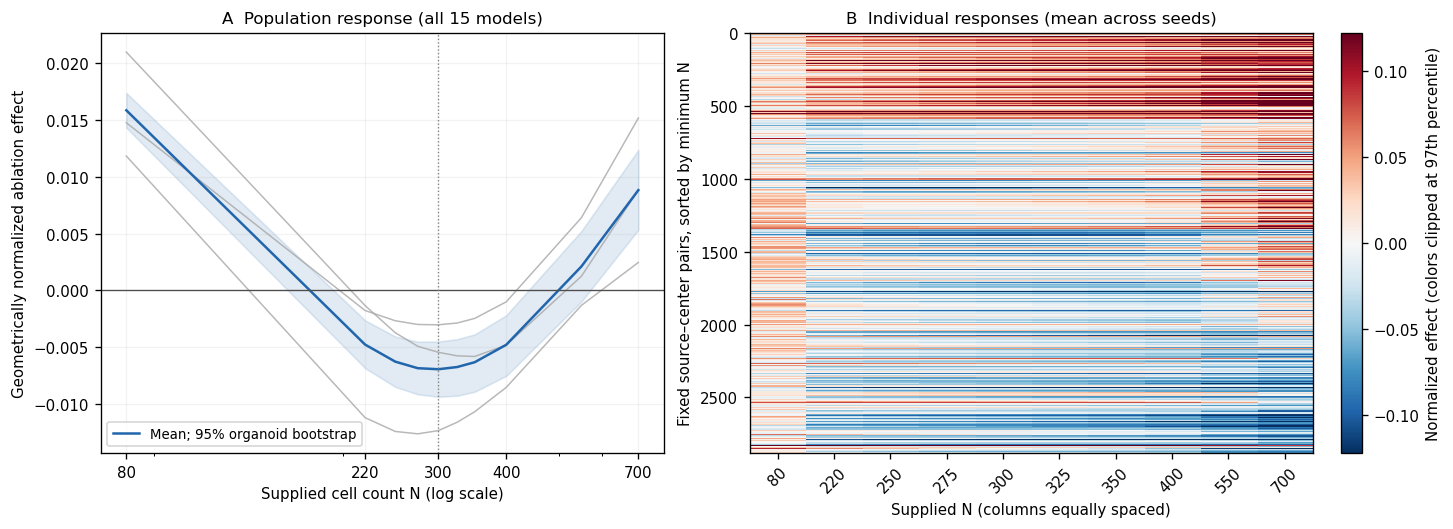

In [2]:
show(plots.response_patterns(OUTPUT), 'figure_1_response_patterns')
print(f"{patterns.local_minimum_near_300.mean():.1%} of pairs have a sampled local minimum within N=250–350; {patterns.sign_changes.gt(0).mean():.1%} change sign on this grid.")
print('These are descriptive fractions of seed-averaged pairs, not organoid-weighted estimates or tests of seed agreement.')

## Figure 2 — One shared PCA coordinate system across sizes

We fit an **unwhitened, unscaled, organoid-weighted PCA** to the final 256-dimensional local embeddings of these KI67-eligible LGR5 centers, pooling intact and KI67-ablated states across the sampled N values. Each organoid has equal total weight, with equal weights for its cases and for the N/ablation conditions. A single basis per checkpoint is then used at every N. Distances are preserved within the retained subspace; discarded dimensions can still contain substantial movement.

Colors annotate the existing GMM clusters fitted in the earlier embedding analysis, **not clusters fitted in this 2-D display**. Assignments are evaluated at the displayed N. Labels are ordered once by median predicted physical curvature residual at N=300 in the current eligible cohort: C1 is lowest. Clusters empty at the reference are gray and have no curvature rank. These are clusters of LGR5 center embeddings, not a clustering of all cell identities. Maps show one illustrative model; neither coordinates nor cluster identities are aligned across checkpoints.

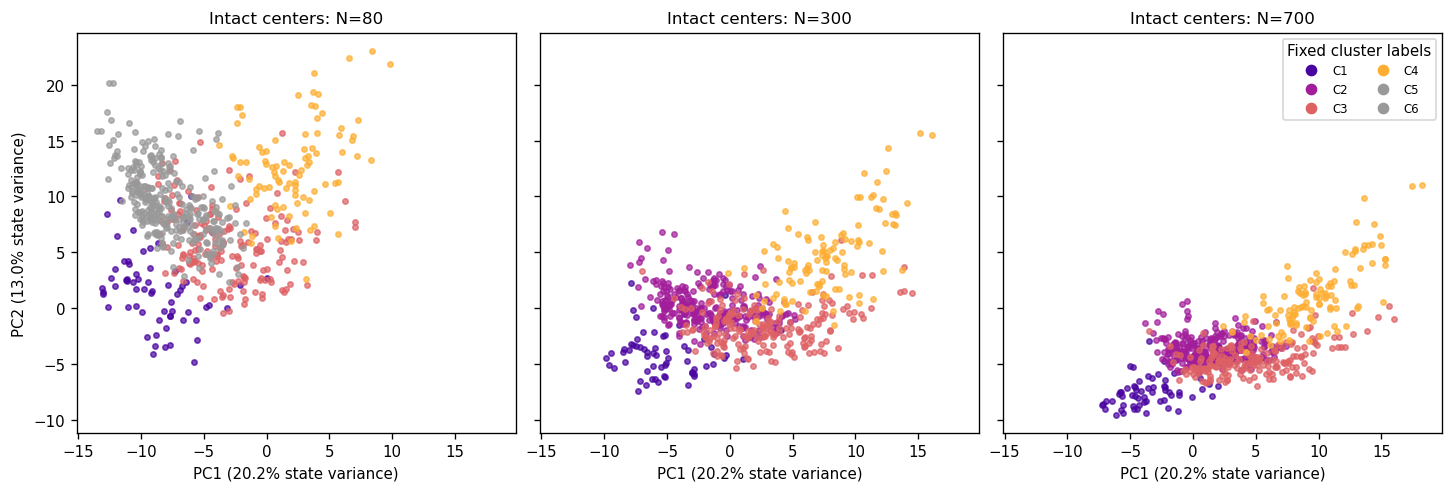

In [3]:
show(plots.state_map(OUTPUT), 'figure_2_shared_state_pca')

## Figure 3 — Movements caused by removing KI67

Top: intact-to-ablated arrows in the same state PCA. Bottom: displacement vectors in a separate **response-oriented linear projection**, fitted by an uncentered weighted SVD of KI67 displacement vectors across N. Its origin represents no ablation, and its axes maximize retained squared displacement without using curvature targets. Both rows use the same fixed subset of source–center pairs at each N. Arrow lengths are not magnified, axes are shared within each row, and colors show the actual full-model normalized response.

The two rows have different bases and should not be overlaid. The response projection makes more of the perturbation visible, but even it may omit directions important to the head. Figure 4 measures this limitation explicitly.

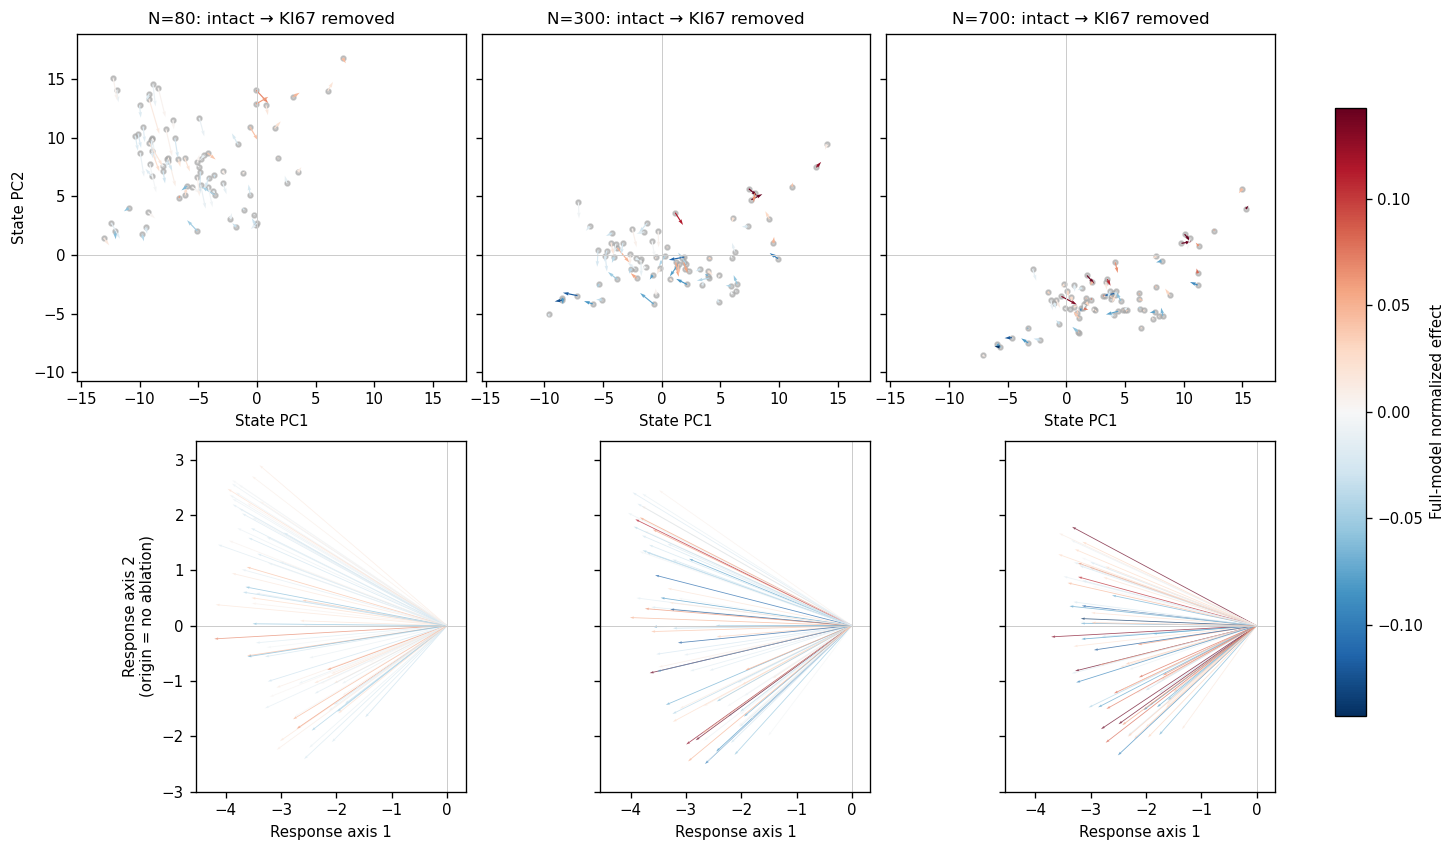

In [4]:
show(plots.ablation_movements(OUTPUT), 'figure_3_ablation_movements')

## Figure 4 — Can reduced-space movement explain the prediction?

For each retained dimension count k, reconstruct the projected displacement \(P_k\Delta h\), add it to the **full intact embedding**, and pass it through the actual head at the same N. This isolates the information lost from the ablation movement. We compare the resulting normalized curvature change with the true full-model effect. The head itself is never refitted.

A: organoid-weighted fraction of squared displacement retained. B: RMSE divided by RMS of the full effect (zero is perfect). C: sign agreement, excluding true normalized effects smaller than \(10^{-8}\) in magnitude. Solid lines use state PCA, dashed lines response SVD. These are descriptive reconstruction checks on the analyzed states, not held-out predictive performance. **A visually short arrow or a high retained state variance does not establish a weak curvature response.**

State PCA, 2 dimensions at N=300: 4.4% of displacement energy retained; response relative RMSE 0.89; sign agreement 65.7%.
Response SVD, 2 dimensions at N=300: 50.2% of displacement energy retained; response relative RMSE 0.90; sign agreement 67.3%.


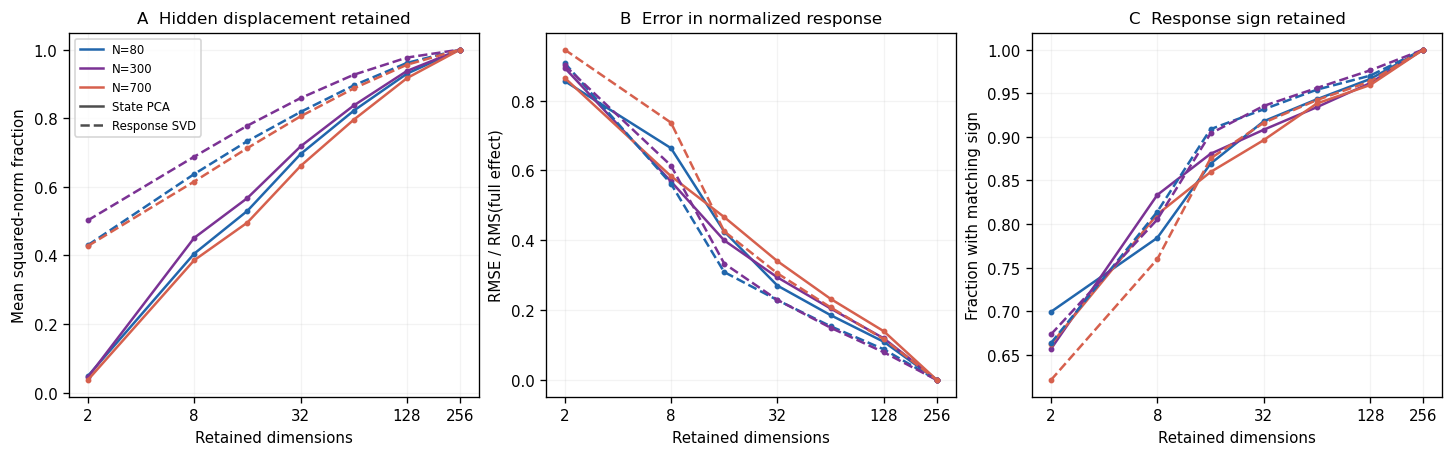

In [5]:
show(plots.projection_fidelity(OUTPUT), 'figure_4_projection_fidelity')
fidelity = pd.read_csv(OUTPUT / 'tables/projection_fidelity.csv')
response_fidelity = pd.read_csv(OUTPUT / 'tables/response_projection_fidelity.csv')
for label, table in [('State PCA', fidelity), ('Response SVD', response_fidelity)]:
    p = table[(table.n == 300) & (table.dimensions == 2)].iloc[0]
    print(f'{label}, 2 dimensions at N=300: {p.retained_energy:.1%} of displacement energy retained; response relative RMSE {p.relative_rmse:.2f}; sign agreement {p.sign_agreement:.1%}.')

## Figure 5 — Separate the displacement from how it is read

This calculation uses **all 256 dimensions**, independently of PCA. For this model's single-ReLU head, the finite ablation effect can be written exactly as \(\Delta z(N)=g(N)^T\Delta h(N)\). Here \(g\) is the activation-averaged readout along the intact-to-ablated segment, not just a gradient at the intact state. It depends on the intact embedding, the ablation displacement, and the head's explicit size input.

A: the actual transformed response versus \(g(300)^T\Delta h(N)\). The latter is an algebraic fixed-readout probe, not a prediction from freezing a nonlinear head. B: between consecutive N values, use the exact symmetric identity
\[
\Delta(\Delta z)=\tfrac12(g_b+g_a)^T(\Delta h_b-\Delta h_a)+\tfrac12(\Delta h_b+\Delta h_a)^T(g_b-g_a).
\]
The two terms accumulate from N=300. Their sum reproduces the response change; their allocation depends on this decomposition and grid. **“Readout change” is not synonymous with “head-only size input”: FiLM can change the intact embedding and therefore the head's activation pattern.**

C: full-space direction similarities to the same pair at N=300 (one by construction there). D: positive and negative hidden-unit contributions within the head, which sum to the net response. These units are computational contributions, not identified biological pathways. Transformed units are retained here because the decomposition is exact on that scale; geometry and inverse transformation can move a population minimum.

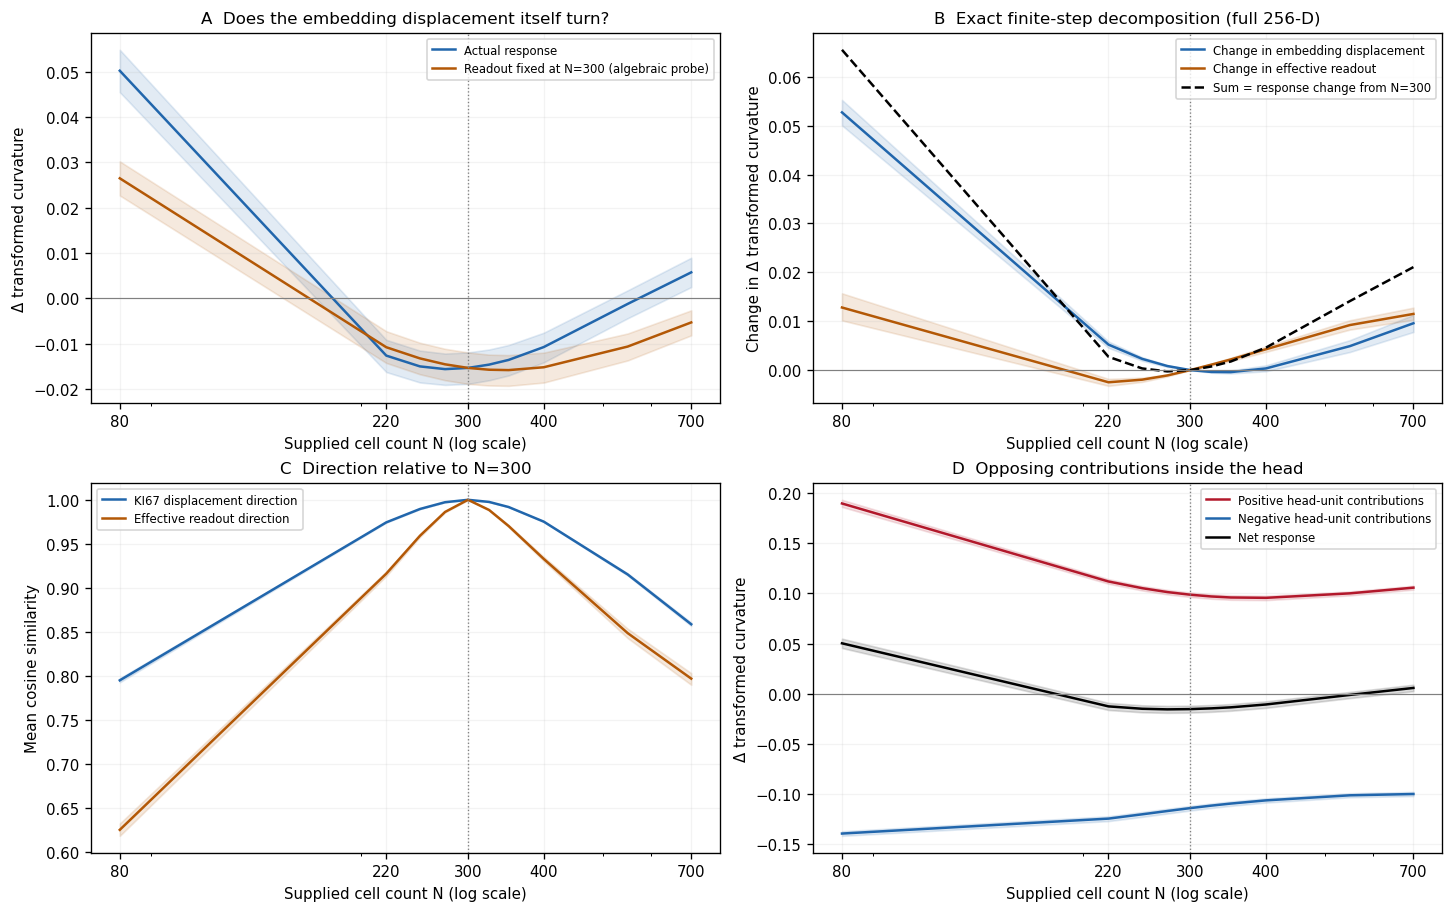

In [6]:
show(plots.readout_mechanism(OUTPUT), 'figure_5_full_space_readout')

**Reading the turning point:** near N=300, changes in the displacement and in its effective readout oppose one another. From 300 to 325, the displacement term is negative while the readout term is positive and larger. The fixed-readout probe turns later and remains negative at N=700, whereas the actual population response has become positive. Thus the upper branch and sign reversal cannot be understood from displacement magnitude alone. This is a decomposition of this fitted model's behavior, not evidence identifying a physical curvature mechanism.

This describes the mean across models. The readout term from N=300 to 325 is positive for all three seed means, but the displacement term is negative for two seeds and positive for one. One seed still has a slightly decreasing transformed response over this interval. The exact location and balance of the turn therefore vary between fitted models.

## Figure 6 — Which neighborhood contexts follow different curves?

A: hop-1 neighbor marker fractions for groups defined by each center's **intact cluster at N=300**. All centers are LGR5-positive and have a KI67-positive hop-1 source. Fractions describe their neighbors, not the center identity. B: follow those same fixed groups across the entire N sweep; no cells enter or leave a group as N changes. Organoids are equally weighted within groups; a single organoid may contribute to several groups. Only groups supported by at least five organoids are plotted.

This is a descriptive context comparison for fold 0, seed 42. It can reveal heterogeneous response shapes, but does not isolate which neighbor marker caused a difference between clusters. Cluster labels have the same N=300 curvature order as Figure 2.

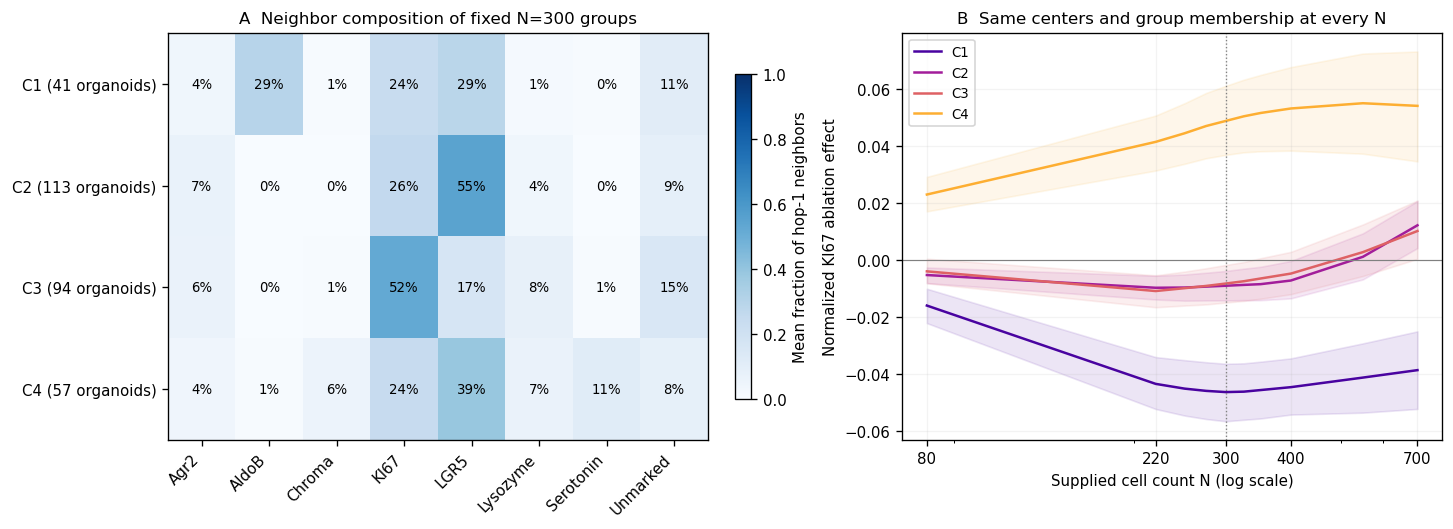

In [7]:
show(plots.neighborhood_context(OUTPUT), 'figure_6_fixed_contexts')

## Figure 7 — Other marker removals as direction probes

To provide context for KI67, remove one positive hop-1 source of another marker while preserving the same LGR5 center. Sources are fixed across N. Each marker uses the subset of KI67-eligible centers where that marker is present, so **support differs between markers**; this is not a marker-importance ranking.

A: mean displacement arrows in the unchanged state PCA at N=300. Faint arrows show KI67 on exactly the same centers as their corresponding colored marker. B: cosine similarity between the other-marker and KI67 displacement, paired at each center and measured in **all 256 dimensions**, then averaged within organoids. C: how much of that marker's squared displacement is visible in the 2-D state PCA. These illustrative probes use fold 0, seed 42 only. Directions can be compared within this model; hidden axes have no assigned biological meaning.

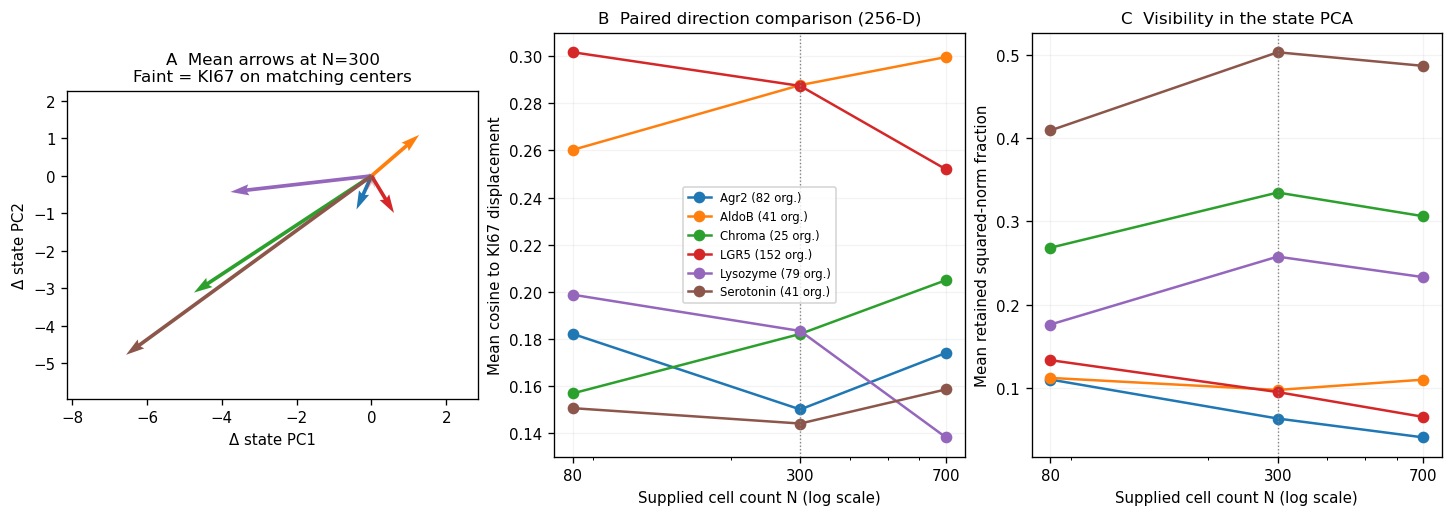

In [8]:
show(plots.other_marker_probes(OUTPUT), 'figure_7_other_marker_probes')

## Scope and reproducibility

All 15 checkpoints completed. Saved scalar KI67 responses were checked against the new/reused embeddings at every supplied N. Tests verify orthogonal projections, retention of a nonzero mean displacement in response SVD, the exact finite-ablation head calculation across ReLU crossings, and the finite-step decomposition. Full-dimensional reconstruction provides an additional numerical check.

The main curves use 2,881 fixed pairs from 823 validation organoids. Per-case and per-organoid tables, projection objects, sampled states and PNG/PDF figures are saved under `ki67_hop1_pca_v1` beside the earlier analysis. The original trained models and earlier result directories are retained. Setting `RUN_ANALYSIS=True` resumes missing work and otherwise reuses completed results.

These are counterfactual size sweeps on fixed observed graphs. A marker removal does not remove a cell or simulate tissue relaxation. N is a size proxy in destructive snapshots, not a longitudinal crypt-development measurement. The sampled minimum and conditional intervals should be read with those limits in mind.